In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch
import matplotlib.pyplot as plt
import numpy as np

from torchvision.transforms import AutoAugment, AutoAugmentPolicy

from tqdm import tqdm
import PIL as PIL

# Runtime detection and misc variables

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Running the notebook with device = {device}")

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse','ship', 'truck')

Running the notebook with device = cuda


# Utilities to get the dataset and apply data augmentation

In [3]:
def load_datasets(augment=False):
    mean = [0.4914, 0.4822, 0.4465]
    std  = [0.2470, 0.2435, 0.2616]
    # define the data augmentation transform for the train set
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
        transforms.RandomErasing(p=0.5, scale=(0.02, 0.33))
    ])
    # define the normal transform for the validation and test set
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_data = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True,
        transform = train_transform if augment else test_transform
    )

    test_data = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True,
        transform=test_transform
    )
    return train_data, test_data

def get_loaders(train_set, test_set, bsize=128):
    # Get the dataloaders with a user decided batch size for a train and test set
    train_loader = DataLoader(
        train_set, batch_size=bsize, shuffle=True, num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_set, batch_size=bsize, shuffle=False, num_workers=2, pin_memory=True
    )
    return train_loader, test_loader

# Architecture definition

In [4]:
class ResBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super(ResBlock, self).__init__()
        self.conv_1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bnorm_1 = nn.BatchNorm2d(out_channels)

        self.conv_2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bnorm_2 = nn.BatchNorm2d(out_channels)
        # Each residual block has a skip connection, this is what separates
        # residual networks from the architectures that were previously used.
        # If the dimensions and stride allow it, the skip connection is the
        # identity mapping (used to propagate the block input forward).
        # If the dimensions do not match (or stride != 1) we have to use a
        # projection mapping to match the dimensions
        self.skip_connection = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip_connection = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        # The idea of a forward pass is to have a H(x) = F(x) + x, where F(x)
        # is the result of the first and second convolutional layers (residual
        # path) and x is the input that gets propagated via the skip connection.
        out = F.relu(self.bnorm_1(self.conv_1(x)))
        out = self.bnorm_2(self.conv_2(out))
        out += self.skip_connection(x)
        out = F.relu(out)
        return out

class ResNet34(nn.Module):

    def __init__(self):
        super(ResNet34, self).__init__()
        # Initial convolutional layer with batchnorm
        self.conv_1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bnorm_1 = nn.BatchNorm2d(64)
        # Residual blocks configuration
        self.res_1 = self.make_blocks(64,  64,  3, 1)
        self.res_2 = self.make_blocks(64,  128, 4, 2)
        self.res_3 = self.make_blocks(128, 256, 6, 2)
        self.res_4 = self.make_blocks(256, 512, 3, 2)
        # Final classification layer
        self.linear = nn.Linear(512, 10)

    def make_blocks(self, in_chs, out_chs, nblocks, stride):
        layers = []
        layers.append(ResBlock(in_chs, out_chs, stride))
        for _ in range(1, nblocks):
            layers.append(ResBlock(out_chs, out_chs, stride=1))

        return nn.Sequential(*layers)

    def forward(self, x):
        # initial conv layer
        out = F.relu(self.bnorm_1(self.conv_1(x)))
        # pass through the residual blocks
        out = self.res_1(out)
        out = self.res_2(out)
        out = self.res_3(out)
        out = self.res_4(out)
        # global average pooling
        out = F.avg_pool2d(out, 4)
        # flatten and classify
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

# Training setup

In [5]:
class EarlyStopping:

    def __init__(self, min_delta, patience):
        self.min_delta = min_delta
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.best_epoch = 0

    def step(self, val_loss, epoch, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_epoch = epoch
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience


def train_one_epoch(model, loader, criterion, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for x, y in tqdm(loader, desc="Training", leave=False):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Evaluating", leave=False):
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), 100. * correct / total



# Hyperparameters setup
NUM_EPOCHS    = 100
BATCH_SIZE    = 128
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 5e-4
PATIENCE      = 15
MIN_DELTA     = 1e-3

train_set_full_aug, test_set = load_datasets(augment=True)
train_set_full_clean, _ = load_datasets(augment=False)
train_size = int(0.9 * len(train_set_full_aug))
val_size = len(train_set_full_aug) - train_size

# generator = torch.Generator().manual_seed(42)
train_indices, val_indices = random_split(
    range(len(train_set_full_aug)), [train_size, val_size]
    # generator=generator
)

train_set = torch.utils.data.Subset(train_set_full_aug, train_indices)
val_set = torch.utils.data.Subset(train_set_full_clean, val_indices)
train_loader, _ = get_loaders(train_set, test_set, BATCH_SIZE)
val_loader, test_loader = get_loaders(val_set, test_set, BATCH_SIZE)

# Needed when running in colab
from google.colab import drive
drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/resnet34_best_bettertrain.pth'

Mounted at /content/drive


# Training Loop


In [ ]:
model = ResNet34().to(device)

# Set optimizer and criterion (same as ResNet18 for comparison) and
# setup early stopping and best accuracy for saving
criterion    = nn.CrossEntropyLoss()
optimizer    = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler    = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
early_stop   = EarlyStopping(MIN_DELTA, PATIENCE)
best_val_acc = 0.0

history = { "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [] }

print("[STARTING TRAINING LOOP]")

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scheduler)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] | "
        f"Train Acc: {train_acc:6.2f}% | "
        f"Val Acc: {val_acc:6.2f}%"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'best_val_loss': val_loss,
            'history': history,
        }
        torch.save(checkpoint, save_path)
        print(f"New best model saved - Val Acc: {val_acc:.2f}%")

    if early_stop.step(val_loss, epoch + 1, model):
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print("[ENDING TRAINING LOOP]")
print(f"Best validation loss at epoch {early_stop.best_epoch}")

# Training data plots

In [15]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# show when the best model was saved
highest_val = np.argmax(history["val_acc"])
print(highest_val)
plt.axvline(
    x=highest_val + 1,
    linestyle="--",
    linewidth=2,
    label="highest val epoch"
)

plt.title("Training vs Validation Loss")
plt.show()

In [16]:
plt.figure()
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

# show when the best model was saved
highest_val = np.argmax(history["val_acc"])
print(highest_val)
plt.axvline(
    x=highest_val + 1,
    linestyle="--",
    linewidth=2,
    label="highest val epoch"
)

plt.title("Training vs Validation Accuracy")
plt.show()

In [7]:
model_from_checkpoint = ResNet34().to(device)
checkpoint = torch.load('/content/drive/MyDrive/resnet34_best_bettertrain.pth', map_location=device)
model_from_checkpoint.load_state_dict(checkpoint['model_state_dict'])

model_from_checkpoint.eval()
optimizer = optim.AdamW(model_from_checkpoint.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

test_loss, test_acc = evaluate(model_from_checkpoint, test_loader, criterion)

print(f"Test loss = {test_loss}, Test Accuracy = {test_acc}")

total_params = sum(p.numel() for p in model_from_checkpoint.parameters() if p.requires_grad)
print(f'Total number of parameters: {total_params}')

Test loss = 0.1968116151003898, Test Accuracy = 95.1
Total number of parameters: 21282122


Total test samples: 10000
Overall accuracy: 95.10%


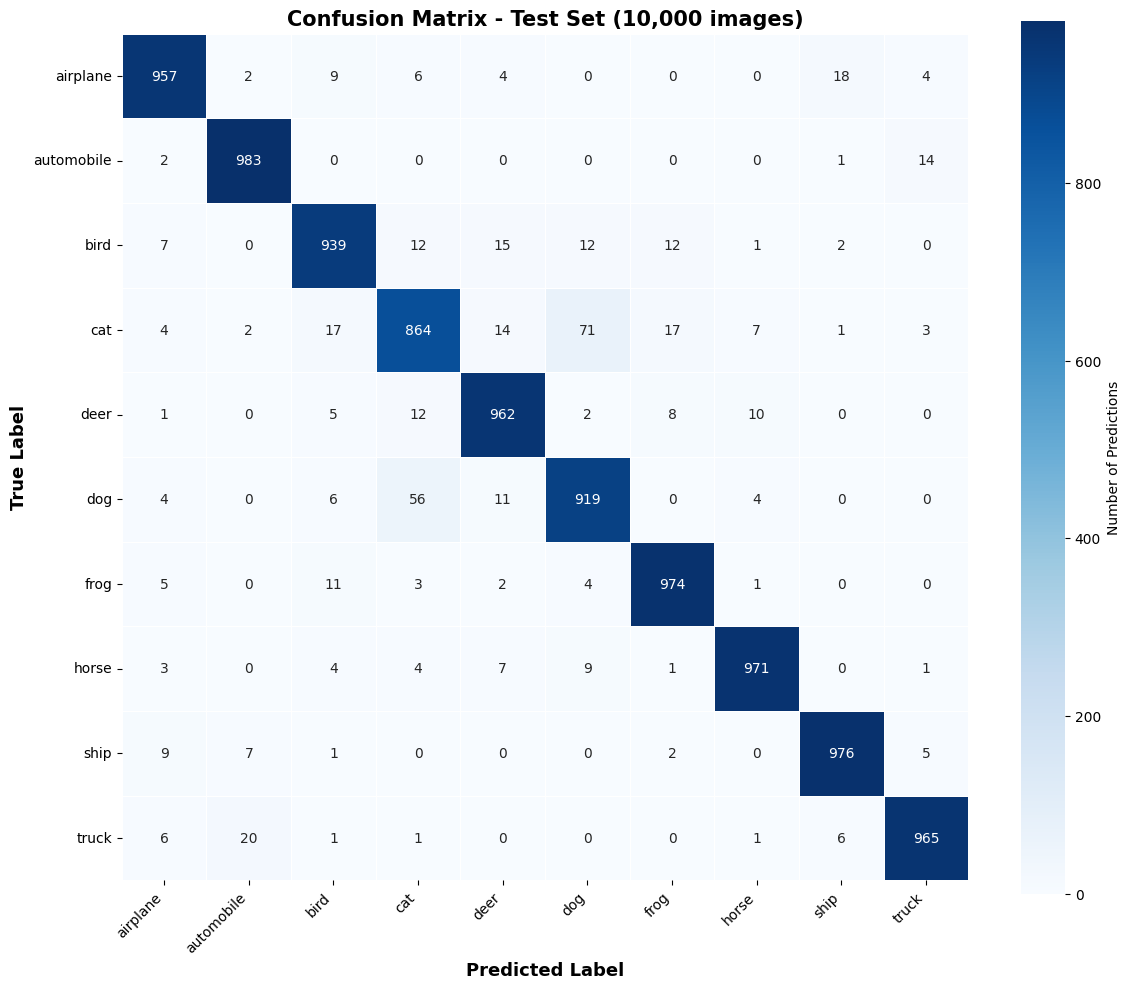

In [8]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

all_preds = []
all_labels = []

model_from_checkpoint.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model_from_checkpoint(x)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Total test samples: {len(all_labels)}")
print(f"Overall accuracy: {100 * (all_preds == all_labels).mean():.2f}%")

cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Number of Predictions'},
            square=True, linewidths=0.5)
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.title('Confusion Matrix - Test Set (10,000 images)', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

Per-Class Accuracy:
airplane    :  957/1000 =  95.70%
automobile  :  983/1000 =  98.30%
bird        :  939/1000 =  93.90%
cat         :  864/1000 =  86.40%
deer        :  962/1000 =  96.20%
dog         :  919/1000 =  91.90%
frog        :  974/1000 =  97.40%
horse       :  971/1000 =  97.10%
ship        :  976/1000 =  97.60%
truck       :  965/1000 =  96.50%
Average:       95.10%
Best:  automobile   (98.30%)
Worst: cat          (86.40%)


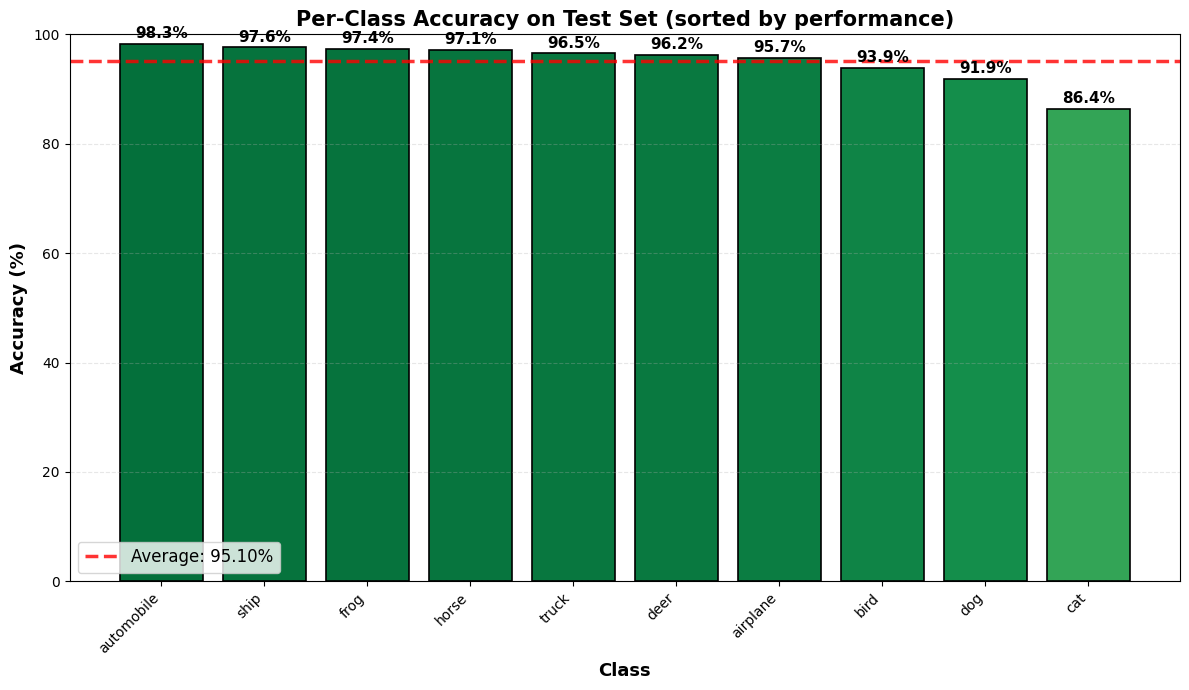

In [9]:
# Calculate per-class accuracy from confusion matrix
class_correct = cm.diagonal()  # Diagonal = correct predictions
class_total = cm.sum(axis=1)   # Row sum = total per class
class_accuracy = 100 * class_correct / class_total

# Print the values
print("Per-Class Accuracy:")
print("="*40)
for i, name in enumerate(class_names):
    print(f"{name:12s}: {class_correct[i]:4.0f}/1000 = {class_accuracy[i]:6.2f}%")
print("="*40)
print(f"Average:      {class_accuracy.mean():6.2f}%")
print(f"Best:  {class_names[class_accuracy.argmax()]:12s} ({class_accuracy.max():.2f}%)")
print(f"Worst: {class_names[class_accuracy.argmin()]:12s} ({class_accuracy.min():.2f}%)")

sorted_indices = np.argsort(class_accuracy)[::-1]
sorted_names = [class_names[i] for i in sorted_indices]
sorted_accuracy = class_accuracy[sorted_indices]

plt.figure(figsize=(12, 7))
colors = plt.cm.RdYlGn(sorted_accuracy / 100)
bars = plt.bar(sorted_names, sorted_accuracy, color=colors, edgecolor='black', linewidth=1.2)

plt.ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
plt.xlabel('Class', fontsize=13, fontweight='bold')
plt.title('Per-Class Accuracy on Test Set (sorted by performance)', fontsize=15, fontweight='bold')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar, acc in zip(bars, sorted_accuracy):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

avg_acc = class_accuracy.mean()
plt.axhline(avg_acc, color='red', linestyle='--', linewidth=2.5,
            label=f'Average: {avg_acc:.2f}%', alpha=0.8)
plt.legend(fontsize=12, loc='lower left')

plt.tight_layout()
plt.show()

In [10]:
class ResNet18(nn.Module):

    def __init__(self):
        super(ResNet18, self).__init__()
        self.conv_1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1,
                                bias=False)
        self.bnorm_1 = nn.BatchNorm2d(64)
        # Residual blocks configuration: after the first layer we use a stride
        # of 2 in order to downsample spatially (since we are modifying the
        # number of channels)
        self.res_1 = self.make_blocks(64,  64,  2, stride=1)
        self.res_2 = self.make_blocks(64,  128, 2, stride=2)
        self.res_3 = self.make_blocks(128, 256, 2, stride=2)
        self.res_4 = self.make_blocks(256, 512, 2, stride=2)
        # Final linear layer that maps to the output classes
        self.linear = nn.Linear(512, 10)

    def forward(self, x):
        out = F.relu(self.bnorm_1(self.conv_1(x)))
        out = self.res_1(out)
        out = self.res_2(out)
        out = self.res_3(out)
        out = self.res_4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

    def make_blocks(self, in_chs, out_chs, n, stride):
        layers = []
        layers.append(ResBlock(in_chs, out_chs, stride))
        for _ in range(1, n):
            layers.append(ResBlock(out_chs, out_chs, 1))
        return nn.Sequential(*layers)


# Train ResNet18 with same approach as ResNet34


In [11]:
from google.colab import drive
drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/resnet18_bettertrain.pth'

model = ResNet18().to(device)

# Set optimizer and criterion (same as ResNet18 for comparison) and
# setup early stopping and best accuracy for saving
criterion    = nn.CrossEntropyLoss()
optimizer    = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler    = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
early_stop   = EarlyStopping(MIN_DELTA, PATIENCE)
best_val_acc = 0.0

history = { "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [] }

print("[STARTING TRAINING LOOP]")

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scheduler)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] | "
        f"Train Acc: {train_acc:6.2f}% | "
        f"Val Acc: {val_acc:6.2f}%"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'best_val_loss': val_loss,
            'history': history,
        }
        torch.save(checkpoint, save_path)
        print(f"New best model saved - Val Acc: {val_acc:.2f}%")

    if early_stop.step(val_loss, epoch + 1, model):
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print("[ENDING TRAINING LOOP]")
print(f"Best validation loss at epoch {early_stop.best_epoch}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[STARTING TRAINING LOOP]


Epoch [  1/100] | Train Acc:  29.93% | Val Acc:  40.12%
New best model saved - Val Acc: 40.12%


Epoch [  2/100] | Train Acc:  45.40% | Val Acc:  58.96%
New best model saved - Val Acc: 58.96%


Epoch [  3/100] | Train Acc:  53.70% | Val Acc:  61.62%
New best model saved - Val Acc: 61.62%


Epoch [  4/100] | Train Acc:  59.45% | Val Acc:  61.42%


...

Epoch [ 90/100] | Train Acc:  94.27% | Val Acc:  95.50%


Epoch [ 91/100] | Train Acc:  94.35% | Val Acc:  95.54%


Epoch [ 92/100] | Train Acc:  94.26% | Val Acc:  95.64%


Epoch [ 93/100] | Train Acc:  94.16% | Val Acc:  95.60%


Epoch [ 94/100] | Train Acc:  94.34% | Val Acc:  95.56%

Early stopping triggered at epoch 94
[ENDING TRAINING LOOP]
Best validation loss at epoch 79


# Training Plots


78


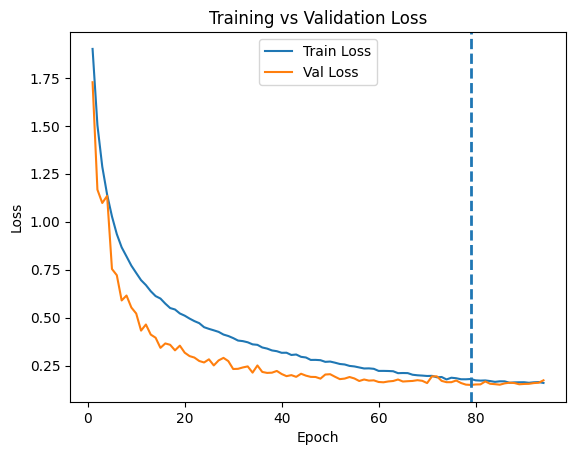

In [12]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# show when the best model was saved
highest_val = np.argmax(history["val_acc"])
print(highest_val)
plt.axvline(
    x=highest_val + 1,
    linestyle="--",
    linewidth=2,
    label="highest val epoch"
)

plt.title("Training vs Validation Loss")
plt.show()

78


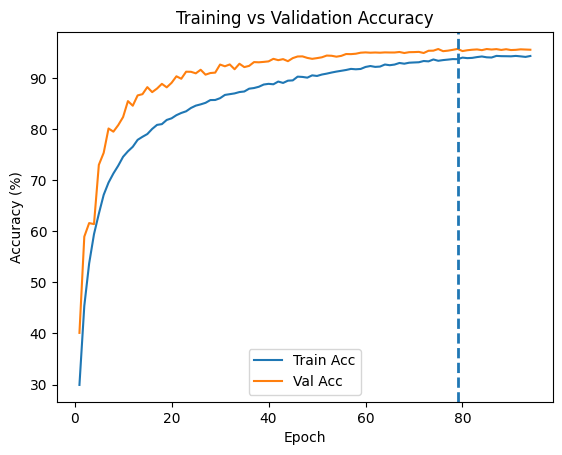

In [13]:
plt.figure()
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

# show when the best model was saved
highest_val = np.argmax(history["val_acc"])
print(highest_val)
plt.axvline(
    x=highest_val + 1,
    linestyle="--",
    linewidth=2,
    label="highest val epoch"
)

plt.title("Training vs Validation Accuracy")
plt.show()

In [14]:
model_from_checkpoint = ResNet18().to(device)
checkpoint = torch.load('/content/drive/MyDrive/resnet18_bettertrain.pth', map_location=device)
model_from_checkpoint.load_state_dict(checkpoint['model_state_dict'])

model_from_checkpoint.eval()
optimizer = optim.AdamW(model_from_checkpoint.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

test_loss, test_acc = evaluate(model_from_checkpoint, test_loader, criterion)

print(f"Test loss = {test_loss}, Test Accuracy = {test_acc}")

total_params = sum(p.numel() for p in model_from_checkpoint.parameters() if p.requires_grad)
print(f'Total number of parameters: {total_params}')

Test loss = 0.2066902129710475, Test Accuracy = 94.61
Total number of parameters: 11173962


Total test samples: 10000
Overall accuracy: 94.61%


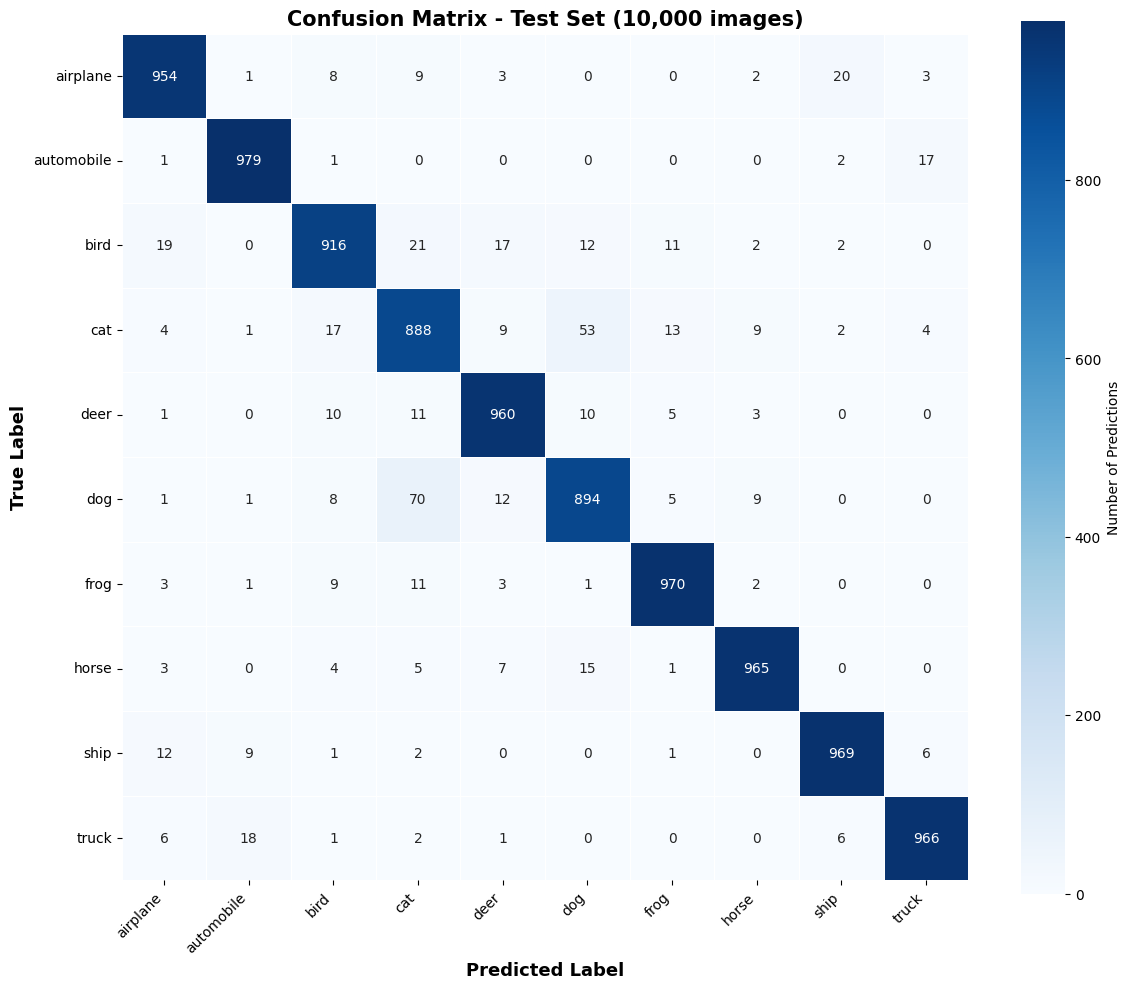

In [15]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

all_preds = []
all_labels = []

model_from_checkpoint.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model_from_checkpoint(x)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Total test samples: {len(all_labels)}")
print(f"Overall accuracy: {100 * (all_preds == all_labels).mean():.2f}%")

cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Number of Predictions'},
            square=True, linewidths=0.5)
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.title('Confusion Matrix - Test Set (10,000 images)', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

Per-Class Accuracy:
airplane    :  954/1000 =  95.40%
automobile  :  979/1000 =  97.90%
bird        :  916/1000 =  91.60%
cat         :  888/1000 =  88.80%
deer        :  960/1000 =  96.00%
dog         :  894/1000 =  89.40%
frog        :  970/1000 =  97.00%
horse       :  965/1000 =  96.50%
ship        :  969/1000 =  96.90%
truck       :  966/1000 =  96.60%
Average:       94.61%
Best:  automobile   (97.90%)
Worst: cat          (88.80%)


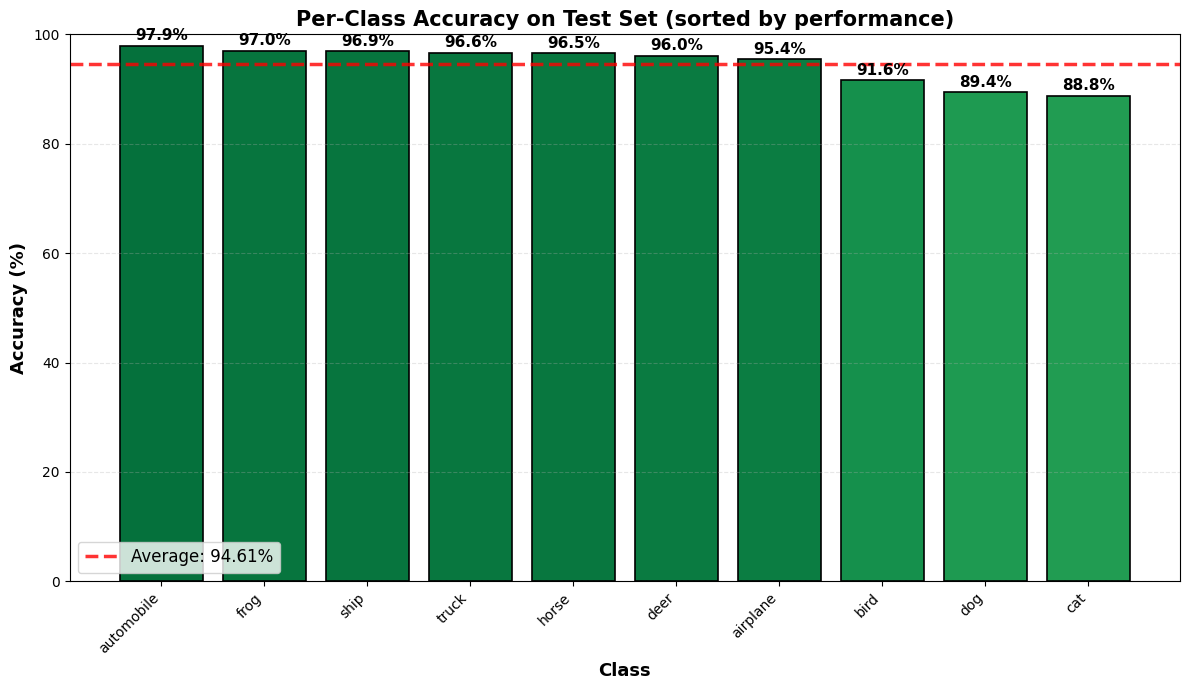

In [16]:
# Calculate per-class accuracy from confusion matrix
class_correct = cm.diagonal()  # Diagonal = correct predictions
class_total = cm.sum(axis=1)   # Row sum = total per class
class_accuracy = 100 * class_correct / class_total

# Print the values
print("Per-Class Accuracy:")
print("="*40)
for i, name in enumerate(class_names):
    print(f"{name:12s}: {class_correct[i]:4.0f}/1000 = {class_accuracy[i]:6.2f}%")
print("="*40)
print(f"Average:      {class_accuracy.mean():6.2f}%")
print(f"Best:  {class_names[class_accuracy.argmax()]:12s} ({class_accuracy.max():.2f}%)")
print(f"Worst: {class_names[class_accuracy.argmin()]:12s} ({class_accuracy.min():.2f}%)")

sorted_indices = np.argsort(class_accuracy)[::-1]
sorted_names = [class_names[i] for i in sorted_indices]
sorted_accuracy = class_accuracy[sorted_indices]

plt.figure(figsize=(12, 7))
colors = plt.cm.RdYlGn(sorted_accuracy / 100)
bars = plt.bar(sorted_names, sorted_accuracy, color=colors, edgecolor='black', linewidth=1.2)

plt.ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
plt.xlabel('Class', fontsize=13, fontweight='bold')
plt.title('Per-Class Accuracy on Test Set (sorted by performance)', fontsize=15, fontweight='bold')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar, acc in zip(bars, sorted_accuracy):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

avg_acc = class_accuracy.mean()
plt.axhline(avg_acc, color='red', linestyle='--', linewidth=2.5,
            label=f'Average: {avg_acc:.2f}%', alpha=0.8)
plt.legend(fontsize=12, loc='lower left')

plt.tight_layout()
plt.show()